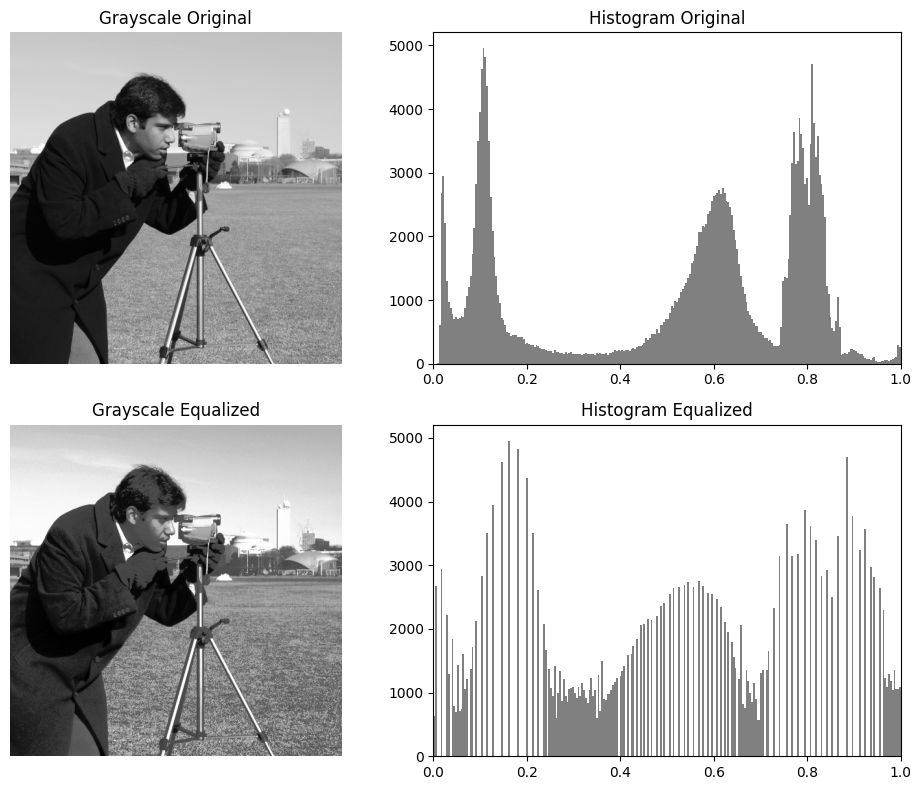

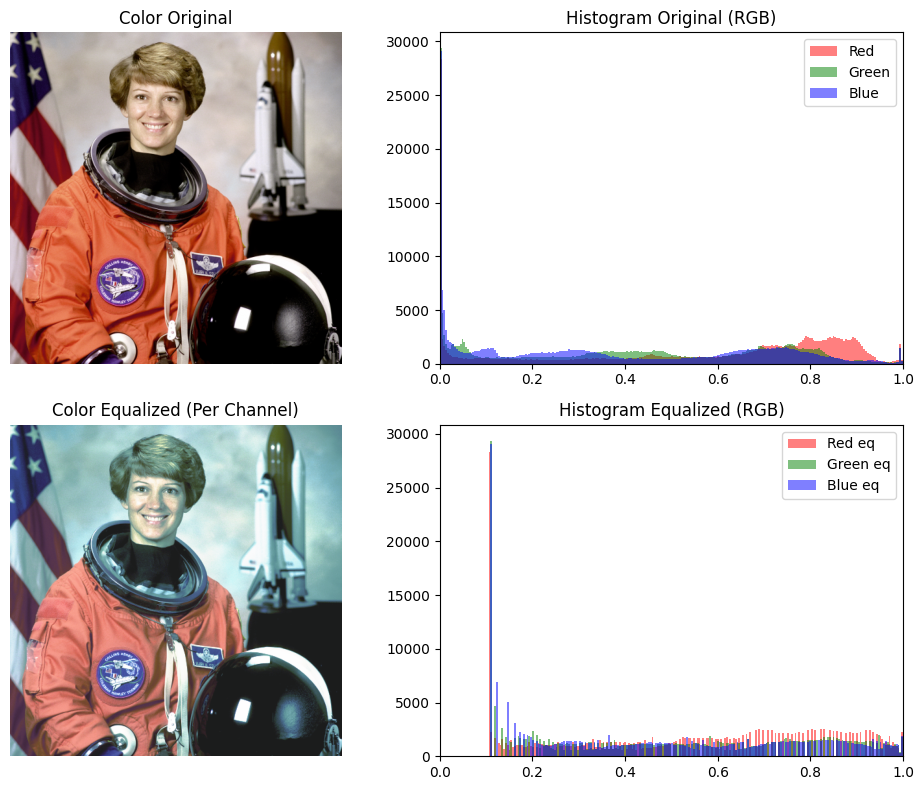

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# ===============================
# BAGIAN 1: GRAYSCALE
# ===============================
image_gray_uint8 = data.camera()
image_gray = img_as_float(image_gray_uint8)

# Histogram citra asli
a = image_gray.ravel()
hist_gray, bins_gray = np.histogram(a, bins=256, range=(0, 1))

# Ekualisasi histogram
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0, 1))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

axes[0, 1].hist(a, bins=256, range=(0, 1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0, 1)

axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0, 1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

# ===============================
# BAGIAN 2: COLOR RGB
# ===============================
image_color_uint8 = data.astronaut()
image_color = img_as_float(image_color_uint8)

r_channel = image_color[:, :, 0]
g_channel = image_color[:, :, 1]
b_channel = image_color[:, :, 2]

# Ekualisasi per kanal
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0, 1)
axes2[0, 1].legend(loc='upper right')

axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized (Per Channel)")
axes2[1, 0].axis('off')

axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0, 1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()